In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv("placement.csv")
df.head() 

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'package')

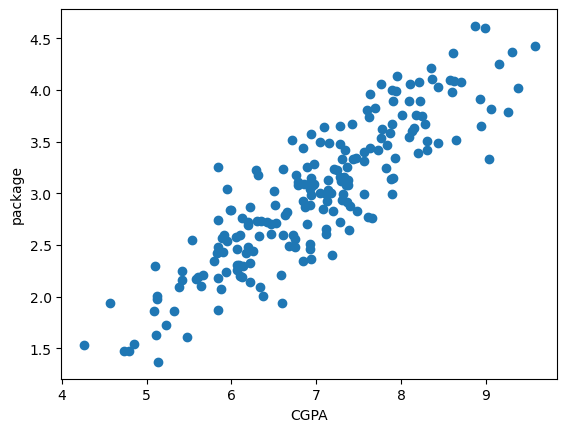

In [3]:
plt.scatter(x=df["cgpa"],y=df["package"])
plt.xlabel("CGPA")
plt.ylabel("package")

In [4]:
x = df.iloc[:,0:1] 
y = df.iloc[:,-1]
y.head()

0    3.26
1    1.98
2    3.25
3    3.67
4    3.57
Name: package, dtype: float64

In [5]:
from sklearn.model_selection import train_test_split 
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.3,random_state=0)

In [6]:
from sklearn.linear_model import LinearRegression 
lr = LinearRegression() 
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
m = lr.coef_[0]
m

np.float64(0.5894808483026014)

In [8]:
c= lr.intercept_
c 

np.float64(-1.1035782225186663)

In [9]:
lr.predict([[9.9]])

C:\Users\susha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([4.73228218])

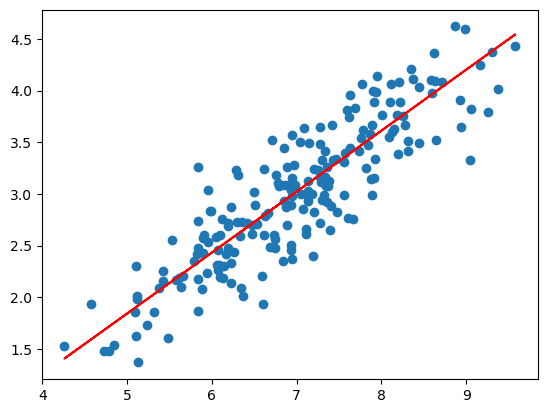

In [10]:
plt.scatter(df["cgpa"],df["package"])
plt.plot(x_train,lr.predict(x_train),color="red")

<Axes: xlabel='cgpa', ylabel='package'>

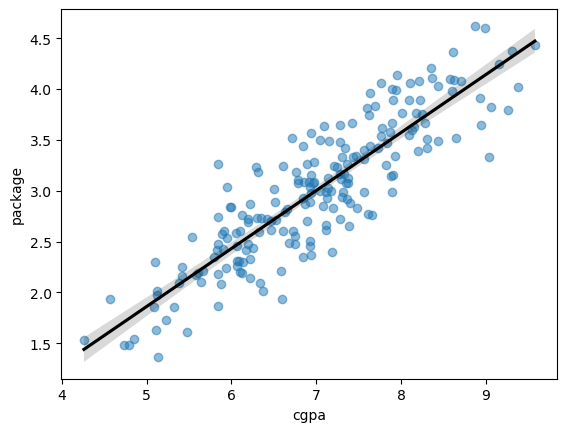

In [11]:
sns.regplot(x="cgpa",y="package",data=df,line_kws={"color":"black"},scatter_kws={"alpha":0.5})

In [12]:
# fx = float(input())
# fy = m*fx + c
# print(fy)

In [13]:
predicted_y = lr.predict(x_test)

In [14]:
df2 = pd.DataFrame({
    "Actual":y_test, 
    "Predicted":predicted_y
})
df2

,Actual,Predicted
18,2.98,2.987419
170,2.87,2.562993
107,2.59,2.627836
98,3.83,3.429530
177,3.64,3.075841
182,2.08,2.362569
5,2.99,3.547426
146,2.46,2.474571
12,3.65,4.166381
152,3.08,3.240896


In [15]:
from sklearn.metrics import r2_score 
score = r2_score(y_test,predicted_y)
print(score)

0.7509091646328011


In [16]:
from sklearn.model_selection import cross_val_score
mse = cross_val_score(lr,x,y,scoring="neg_mean_squared_error",cv=5)
mean_mse = np.mean(mse)
print(mean_mse)

-0.10802197277743579


AttributeError: 'LinearRegression' object has no attribute 'transform'

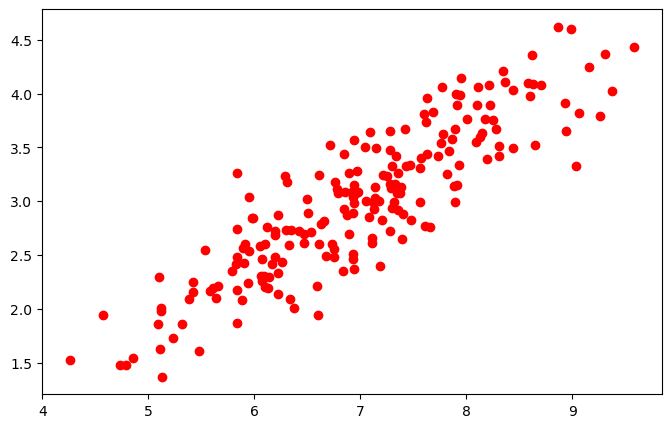

In [21]:
X_grid = np.arange(min(df['cgpa']), max(df['package']), 0.1).reshape(-1,1)
plt.figure(figsize=(8,5))
plt.scatter(x, y, color='red', label='Actual Data')
plt.plot(X_grid,
         lr.predict(lr.transform(X_grid)),
         color='blue',
         label='Polynomial Regression')
plt.title("Polynomial Regression")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.legend()
plt.show()

In [17]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge() 
parameters = {"alpha":[1e-15,1e-10,1e-8,1e-5,1e-3,1e-2,1,5,10,20,30,35,40,45,50,55,100]}

ridge_regressor = GridSearchCV(ridge,parameters,scoring="neg_mean_squared_error",cv=5)
ridge_regressor.fit(x,y)

,estimator,Ridge()
,param_grid,"{'alpha': [1e-15, 1e-10, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,1e-15


In [18]:
print(ridge_regressor.best_params_)
print(ridge_regressor.best_score_)

{'alpha': 1e-15}
-0.10802197277743579
